========================================

FULL DATASET

=======================================================

In [1]:
# load df_full

In [27]:
import numpy as np
import pandas as pd

gemini_cols = [f"{v}_gemini" for v in values_list]


# Aggregate profile
profile = []

for v in values_list:
    col = f"{v}_gemini"
    s = df_full[col].dropna()

    profile.append({
        "value": v,
        "mean_score": s.mean(),
        "median_score": s.median(),
        "q25": s.quantile(0.25),
        "q75": s.quantile(0.75),
        "sd": s.std(),
        "n": s.notna().sum()
    })

profile = pd.DataFrame(profile)

# rank: 1 = highest mean score
profile["rank"] = profile["mean_score"].rank(
    ascending=False,
    method="min"
).astype(int)

profile = profile.sort_values(
    "mean_score",
    ascending=False
).reset_index(drop=True)

profile

N posts: 1105085
                           count      mean       std       min       max
Self-direction_gemini  1105085.0  0.213614  0.297607  0.000032  0.999877
Stimulation_gemini     1105085.0  0.103148  0.211467  0.000015  0.999874
Hedonism_gemini        1105085.0  0.187343  0.285973  0.000027  0.999662
Achievement_gemini     1105085.0  0.124317  0.252567  0.000024  0.999961
Power_gemini           1105085.0  0.054004  0.135070  0.000013  0.995722
Security_gemini        1105085.0  0.196662  0.275408  0.000069  0.999738
Conformity_gemini      1105085.0  0.046963  0.110239  0.000006  0.995850
Tradition_gemini       1105085.0  0.128743  0.265672  0.000023  0.999935
Benevolence_gemini     1105085.0  0.423972  0.402464  0.000036  0.999966
Universalism_gemini    1105085.0  0.140093  0.241607  0.000015  0.999835


,value,mean_score,median_score,q25,q75,sd,n,rank
0,Benevolence,0.423972,0.271544,0.026258,0.893863,0.402464,1105085,1
1,Self-direction,0.213614,0.053891,0.008834,0.312956,0.297607,1105085,2
2,Security,0.196662,0.064013,0.016331,0.247291,0.275408,1105085,3
3,Hedonism,0.187343,0.035473,0.005668,0.237485,0.285973,1105085,4
4,Universalism,0.140093,0.022409,0.003296,0.146618,0.241607,1105085,5
5,Tradition,0.128743,0.011126,0.002867,0.070762,0.265672,1105085,6
6,Achievement,0.124317,0.011972,0.002469,0.079702,0.252567,1105085,7
7,Stimulation,0.103148,0.012270,0.002549,0.074971,0.211467,1105085,8
8,Power,0.054004,0.005576,0.001360,0.029373,0.135070,1105085,9
9,Conformity,0.046963,0.007721,0.001954,0.034638,0.110239,1105085,10


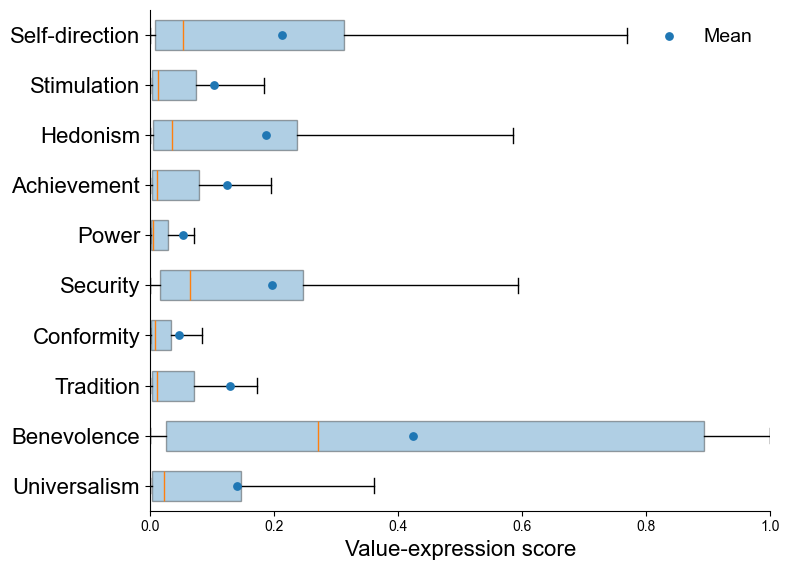

In [61]:
fig, ax = plt.subplots(figsize=(8.0, 5.8))

bp = ax.boxplot(
    data,
    positions=np.arange(len(values_list)),
    vert=False,
    widths=0.6,
    showfliers=False,   
                        
    patch_artist=True
)

for box in bp["boxes"]:
    box.set_alpha(0.35)

# means
ax.scatter(
    means,
    np.arange(len(values_list)),
    s=28,
    zorder=3,
    label="Mean",

)

ax.set_yticks(np.arange(len(values_list)))
ax.set_yticklabels(values_list,  fontsize=16)

ax.invert_yaxis()

ax.set_xlim(0, 1)
ax.set_xlabel("Value-expression score", fontsize=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=14)

plt.tight_layout()

plt.savefig(
    "./img/value_scores_boxplot.png",
    bbox_inches="tight"
)

plt.show()

In [29]:
# one mean value profile per user
user_value_means = (
    df_full
    .groupby("user_idh")[gemini_cols]
    .mean()
)

user_profile = []

for v in values_list:
    col = f"{v}_gemini"
    s = user_value_means[col].dropna()

    user_profile.append({
        "value": v,
        "user_weighted_mean": s.mean(),
        "n_users": s.notna().sum()
    })

user_profile = pd.DataFrame(user_profile)

profile_compare = profile.merge(
    user_profile,
    on="value",
    how="left"
)

profile_compare["difference_user_minus_post"] = (
    profile_compare["user_weighted_mean"]
    - profile_compare["mean_score"]
)

profile_compare[
    [
        "value",
        "rank",
        "mean_score",
        "user_weighted_mean",
        "difference_user_minus_post"
    ]
].sort_values("rank")

,value,rank,mean_score,user_weighted_mean,difference_user_minus_post
0,Benevolence,1,0.423972,0.471073,0.047101
1,Self-direction,2,0.213614,0.173673,-0.039942
2,Security,3,0.196662,0.162280,-0.034381
3,Hedonism,4,0.187343,0.177474,-0.009870
4,Universalism,5,0.140093,0.113318,-0.026775
5,Tradition,6,0.128743,0.107414,-0.021329
6,Achievement,7,0.124317,0.124924,0.000606
7,Stimulation,8,0.103148,0.095440,-0.007708
8,Power,9,0.054004,0.045687,-0.008316
9,Conformity,10,0.046963,0.040470,-0.006492


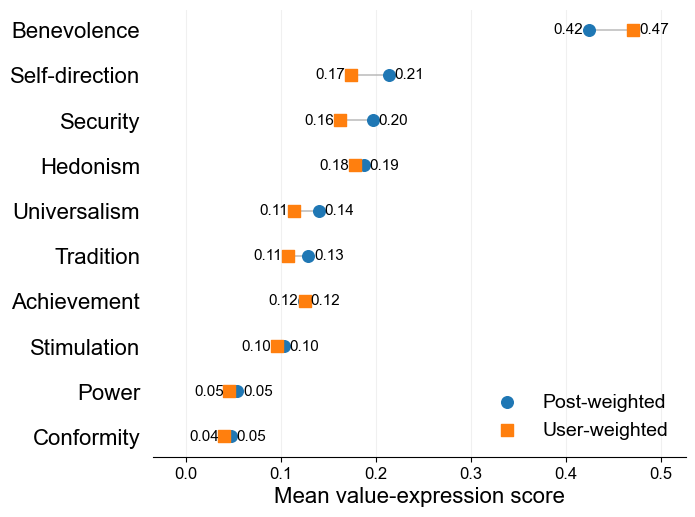

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib as mpl

# -------------------------
# Font
# -------------------------
arial_path = "./img/arial.ttf"
font_manager.fontManager.addfont(arial_path)
arial_prop = font_manager.FontProperties(fname=arial_path)
mpl.rcParams["font.family"] = arial_prop.get_name()

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# -------------------------
# Data
# -------------------------
plot_df = (
    profile_compare
    .sort_values("mean_score", ascending=False)
    .reset_index(drop=True)
    .copy()
)

y = np.arange(len(plot_df))

# -------------------------
# Figure
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 5.2))

post_color = "#1f77b4"
user_color = "#ff7f0e"

# connecting lines
for i, row in plot_df.iterrows():
    ax.plot(
        [row["mean_score"], row["user_weighted_mean"]],
        [i, i],
        color="0.65",
        linewidth=1.2,
        alpha=0.7,
        zorder=1
    )

# post-weighted points
ax.scatter(
    plot_df["mean_score"],
    y,
    s=70,
    marker="o",
    color=post_color,
    label="Post-weighted",
    zorder=2
)

# user-weighted points
ax.scatter(
    plot_df["user_weighted_mean"],
    y,
    s=70,
    marker="s",
    color=user_color,
    label="User-weighted",
    zorder=2
)

# -------------------------
# Labels
# -------------------------
ax.set_yticks(y)
ax.set_yticklabels(plot_df["value"], fontsize=16)
ax.invert_yaxis()

ax.set_xlabel("Mean value-expression score", fontsize=16)
ax.set_ylabel("")

# -------------------------
# Exact values
# -------------------------
for i, row in plot_df.iterrows():

    post = row["mean_score"]
    user = row["user_weighted_mean"]

    if user >= post:
        ax.text(
            post - 0.006,
            i,
            f"{post:.2f}",
            ha="right",
            va="center",
            fontsize=11
        )
        ax.text(
            user + 0.006,
            i,
            f"{user:.2f}",
            ha="left",
            va="center",
            fontsize=11
        )
    else:
        ax.text(
            user - 0.006,
            i,
            f"{user:.2f}",
            ha="right",
            va="center",
            fontsize=11
        )
        ax.text(
            post + 0.006,
            i,
            f"{post:.2f}",
            ha="left",
            va="center",
            fontsize=11
        )

# -------------------------
# Appearance
# -------------------------
xmax = max(
    plot_df["mean_score"].max(),
    plot_df["user_weighted_mean"].max()
)


ax.set_xlim(-0.035, xmax + 0.055)


ax.set_xticks(np.arange(0, 0.51, 0.1))

ax.grid(
    axis="x",
    alpha=0.18
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.tick_params(axis="y", length=0, pad=9)
ax.tick_params(axis="x", labelsize=12)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=14
)


fig.subplots_adjust(left=0.24, right=0.98, bottom=0.12, top=0.98)

plt.show()

fig.savefig(
    "./img/value_profile_post_user.png",
    bbox_inches="tight"
)

In [63]:


# -------------------------
# Post-level correlations
# -------------------------

corr_spearman = df_full[gemini_cols].corr(method="spearman")
corr_pearson = df_full[gemini_cols].corr(method="pearson")

# cleaner labels
corr_spearman.index = values_list
corr_spearman.columns = values_list


print("Spearman correlations:")
display(corr_spearman.round(3))


Spearman correlations:


,Self-direction,Stimulation,Hedonism,Achievement,Power,Security,Conformity,Tradition,Benevolence,Universalism
Self-direction,1.000,0.402,-0.009,0.460,0.276,-0.053,-0.002,-0.157,-0.469,0.197
Stimulation,0.402,1.000,0.573,0.352,0.056,-0.334,-0.290,-0.154,-0.220,-0.072
Hedonism,-0.009,0.573,1.000,0.069,-0.270,-0.448,-0.312,-0.095,0.230,-0.190
Achievement,0.460,0.352,0.069,1.000,0.531,-0.028,0.095,0.060,-0.265,0.034
Power,0.276,0.056,-0.270,0.531,1.000,0.328,0.369,0.041,-0.398,0.093
Security,-0.053,-0.334,-0.448,-0.028,0.328,1.000,0.477,0.227,-0.095,0.206
Conformity,-0.002,-0.290,-0.312,0.095,0.369,0.477,1.000,0.508,-0.006,0.173
Tradition,-0.157,-0.154,-0.095,0.060,0.041,0.227,0.508,1.000,0.164,0.274
Benevolence,-0.469,-0.220,0.230,-0.265,-0.398,-0.095,-0.006,0.164,1.000,-0.290
Universalism,0.197,-0.072,-0.190,0.034,0.093,0.206,0.173,0.274,-0.290,1.000


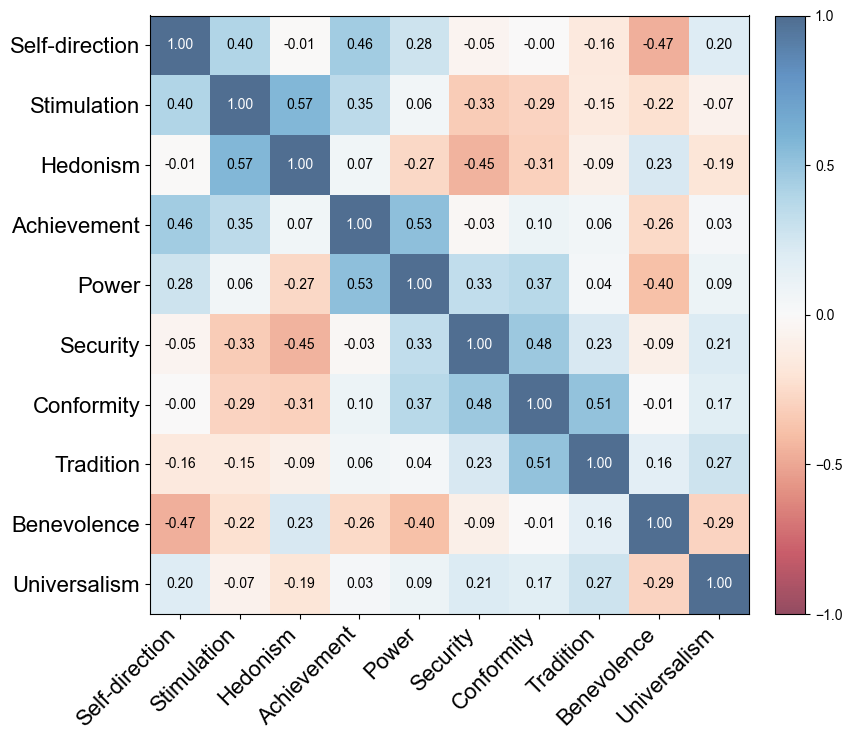

In [64]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(8.5, 7.5))

im = ax.imshow(
    corr_spearman.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu",
    alpha=0.7
)

ax.set_xticks(np.arange(len(values_list)))
ax.set_yticks(np.arange(len(values_list)))

ax.set_xticklabels(values_list, rotation=45, ha="right", fontsize=16)
ax.set_yticklabels(values_list, fontsize=16)

# numbers inside cells
for i in range(len(values_list)):
    for j in range(len(values_list)):
        val = corr_spearman.iloc[i, j]

        rgba = im.cmap(im.norm(val))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]

        text_color = "black" if luminance > 0.5 else "white"

        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color=text_color
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.set_label("Spearman correlation")
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])



plt.tight_layout()
plt.show()

fig.savefig(
    "./img/value_correlations_spearman.png",
    bbox_inches="tight"
)

# number of posts per user

In [31]:
posts_per_user = df_full.groupby("user_idh").size()

posts_per_user.describe(
    percentiles=[.5, .75, .9, .95, .99]
)

count    53606.000000
mean        20.614950
std        115.059131
min          1.000000
50%          3.000000
75%         10.000000
90%         36.000000
95%         79.000000
99%        294.000000
max       8508.000000
dtype: float64

In [32]:
posts_sorted = posts_per_user.sort_values(ascending=False)

for pct in [0.01, 0.05, 0.10]:
    n_top = int(np.ceil(len(posts_sorted) * pct))
    share_posts = posts_sorted.iloc[:n_top].sum() / posts_sorted.sum()
    print(f"Top {pct:.0%} users produce {share_posts:.1%} of posts")

Top 1% users produce 36.1% of posts
Top 5% users produce 63.8% of posts
Top 10% users produce 76.7% of posts


In [63]:
annual_weighting_comparison = []

for v in values_list:

    post = (
        yearly[
            (yearly["value"] == v) &
            (yearly["model"] == "gemini")
        ][["year", "y"]]
        .rename(columns={"y": "post_weighted"})
    )

    user = (
        yearly_user[
            (yearly_user["value"] == v) &
            (yearly_user["model"] == "gemini")
        ][["year", "y"]]
        .rename(columns={"y": "user_weighted"})
    )

    comp = (
        post
        .merge(user, on="year")
        .sort_values("year")
    )

    d_post = comp["post_weighted"].diff()
    d_user = comp["user_weighted"].diff()

    valid = d_post.notna() & d_user.notna()

    directional_agreement = (
        np.sign(d_post[valid]) ==
        np.sign(d_user[valid])
    ).mean()

    mean_abs_difference = (
        comp["post_weighted"] -
        comp["user_weighted"]
    ).abs().mean()

    max_abs_difference = (
        comp["post_weighted"] -
        comp["user_weighted"]
    ).abs().max()

    annual_weighting_comparison.append({
        "value": v,
        "directional_agreement": directional_agreement,
        "mean_abs_difference": mean_abs_difference,
        "max_abs_difference": max_abs_difference
    })

annual_weighting_comparison = pd.DataFrame(
    annual_weighting_comparison
)

annual_weighting_comparison.sort_values(
    "directional_agreement"
)

,value,directional_agreement,mean_abs_difference,max_abs_difference
2,Hedonism,0.6875,0.042593,0.092509
8,Benevolence,0.6875,0.146420,0.305555
1,Stimulation,0.7500,0.032828,0.080485
0,Self-direction,0.7500,0.117288,0.265147
6,Conformity,0.8125,0.064798,0.175756
5,Security,0.8125,0.117376,0.333922
7,Tradition,0.8125,0.070394,0.171499
4,Power,0.8125,0.102166,0.276653
3,Achievement,0.8750,0.030942,0.074664
9,Universalism,0.8750,0.092265,0.182028


In [57]:
temporal_weighting_comparison[
    [
        "pearson_r",
        "spearman_rho",
        "directional_agreement",
        "mean_abs_difference"
    ]
].describe()

,pearson_r,spearman_rho,directional_agreement,mean_abs_difference
count,10.000000,10.000000,10.000000,10.000000
mean,0.905403,0.870628,0.818602,0.057561
std,0.107509,0.167346,0.018876,0.022950
min,0.688600,0.506571,0.784667,0.031671
25%,0.914765,0.866972,0.804679,0.040329
50%,0.944144,0.944910,0.820180,0.045106
75%,0.975148,0.976668,0.831454,0.079736
max,0.982768,0.985787,0.844419,0.093699


In [58]:
temporal_weighting_comparison.sort_values(
    "pearson_r"
)

,value,pearson_r,spearman_rho,directional_agreement,mean_abs_difference
4,Power,0.688600,0.627929,0.784667,0.082750
8,Benevolence,0.725680,0.506571,0.838782,0.093699
6,Conformity,0.908246,0.848477,0.800451,0.047286
0,Self-direction,0.934325,0.922458,0.816234,0.042926
5,Security,0.940390,0.942419,0.801578,0.085072
1,Stimulation,0.947897,0.947401,0.813980,0.039529
2,Hedonism,0.964930,0.959103,0.829763,0.070694
7,Tradition,0.978554,0.983613,0.844419,0.039254
3,Achievement,0.982641,0.982523,0.824126,0.031671
9,Universalism,0.982768,0.985787,0.832018,0.042729


In [59]:
temporal_weighting_comparison.sort_values(
    "mean_abs_difference",
    ascending=False
)

,value,pearson_r,spearman_rho,directional_agreement,mean_abs_difference
8,Benevolence,0.725680,0.506571,0.838782,0.093699
5,Security,0.940390,0.942419,0.801578,0.085072
4,Power,0.688600,0.627929,0.784667,0.082750
2,Hedonism,0.964930,0.959103,0.829763,0.070694
6,Conformity,0.908246,0.848477,0.800451,0.047286
0,Self-direction,0.934325,0.922458,0.816234,0.042926
9,Universalism,0.982768,0.985787,0.832018,0.042729
1,Stimulation,0.947897,0.947401,0.813980,0.039529
7,Tradition,0.978554,0.983613,0.844419,0.039254
3,Achievement,0.982641,0.982523,0.824126,0.031671


# Bot analysis, Botnadzor hashed user IDs

In [51]:

dict_folder = "../dictionaries/"
spam_ids_file = "bots_ids_hashed.txt"

with open(dict_folder + spam_ids_file) as f:
    bot_ids = set(f.read().splitlines())

# make sure types match
df_full["user_idh"] = df_full["user_idh"].astype(str)

flagged_bot_users = set(df_full["user_idh"]) & bot_ids

print("Matched users:", len(flagged_bot_users))
print(
    "Share of users:",
    len(flagged_bot_users) / df_full["user_idh"].nunique()
)

df_full["known_bot"] = df_full["user_idh"].isin(flagged_bot_users)

n_bot_posts = df_full["known_bot"].sum()

print("Matched posts:", n_bot_posts)
print("Share of posts:", n_bot_posts / len(df_full))

Matched users: 44
Share of users: 0.0008208036413834272
Matched posts: 4144
Share of posts: 0.003749937787591


In [52]:
bot_activity = (
    df_full[df_full["known_bot"]]
    .groupby("user_idh")
    .size()
)

nonbot_activity = (
    df_full[~df_full["known_bot"]]
    .groupby("user_idh")
    .size()
)

print("Known bots:")
print(bot_activity.describe(percentiles=[.5, .75, .9, .95, .99]))

print("\nOther users:")
print(nonbot_activity.describe(percentiles=[.5, .75, .9, .95, .99]))

Known bots:
count     44.000000
mean      94.181818
std      150.843716
min        1.000000
50%       15.000000
75%      145.500000
90%      272.800000
95%      438.000000
99%      572.310000
max      651.000000
dtype: float64

Other users:
count    53562.000000
mean        20.554516
std        115.007661
min          1.000000
50%          3.000000
75%         10.000000
90%         36.000000
95%         79.000000
99%        293.000000
max       8508.000000
dtype: float64


In [53]:
df_no_bots = df_full[~df_full["known_bot"]].copy()

profile_no_bots = []

for v in values_list:
    col = f"{v}_gemini"

    profile_no_bots.append({
        "value": v,
        "mean_no_bots": df_no_bots[col].mean()
    })

profile_no_bots = pd.DataFrame(profile_no_bots)

bot_robustness = profile[
    ["value", "mean_score"]
].merge(
    profile_no_bots,
    on="value",
    how="left"
)

bot_robustness["difference"] = (
    bot_robustness["mean_no_bots"]
    - bot_robustness["mean_score"]
)

bot_robustness["relative_difference_pct"] = (
    bot_robustness["difference"]
    / bot_robustness["mean_score"]
    * 100
)

bot_robustness = bot_robustness.sort_values(
    "mean_score",
    ascending=False
)

bot_robustness

,value,mean_score,mean_no_bots,difference,relative_difference_pct
0,Benevolence,0.423972,0.423774,-0.000198,-0.046666
1,Self-direction,0.213614,0.213724,0.000109,0.051091
2,Security,0.196662,0.196315,-0.000346,-0.176059
3,Hedonism,0.187343,0.187354,0.000010,0.005508
4,Universalism,0.140093,0.140042,-0.000051,-0.036492
5,Tradition,0.128743,0.128577,-0.000165,-0.128406
6,Achievement,0.124317,0.124189,-0.000128,-0.103308
7,Stimulation,0.103148,0.103201,0.000053,0.051112
8,Power,0.054004,0.053975,-0.000029,-0.053297
9,Conformity,0.046963,0.046877,-0.000086,-0.182891


In [54]:
from scipy.stats import spearmanr

rho_bot, p_bot = spearmanr(
    bot_robustness["mean_score"],
    bot_robustness["mean_no_bots"]
)

print(f"Spearman rho = {rho_bot:.3f}, p = {p_bot:.4g}")

print(
    "Largest absolute change:",
    bot_robustness["difference"].abs().max()
)

print(
    "Largest relative change:",
    bot_robustness["relative_difference_pct"].abs().max()
)

Spearman rho = 1.000, p = 6.647e-64
Largest absolute change: 0.0003462398482972362
Largest relative change: 0.1828906754673263


In [55]:
bot_profile = []

for v in values_list:
    col = f"{v}_gemini"

    bot_profile.append({
        "value": v,
        "bot_mean": df_full.loc[df_full["known_bot"], col].mean(),
        "other_mean": df_full.loc[~df_full["known_bot"], col].mean()
    })

bot_profile = pd.DataFrame(bot_profile)

bot_profile["difference_bot_other"] = (
    bot_profile["bot_mean"] - bot_profile["other_mean"]
)

bot_profile.sort_values(
    "difference_bot_other",
    key=abs,
    ascending=False
)

,value,bot_mean,other_mean,difference_bot_other
5,Security,0.288647,0.196315,0.092332
8,Benevolence,0.476536,0.423774,0.052761
7,Tradition,0.172662,0.128577,0.044084
3,Achievement,0.158437,0.124189,0.034249
0,Self-direction,0.184620,0.213724,-0.029104
6,Conformity,0.069781,0.046877,0.022904
1,Stimulation,0.089142,0.103201,-0.014059
9,Universalism,0.153675,0.140042,0.013633
4,Power,0.061650,0.053975,0.007675
2,Hedonism,0.184602,0.187354,-0.002752
